Sözlük Boyutu 2
SÖzlük şekli (20, 7)


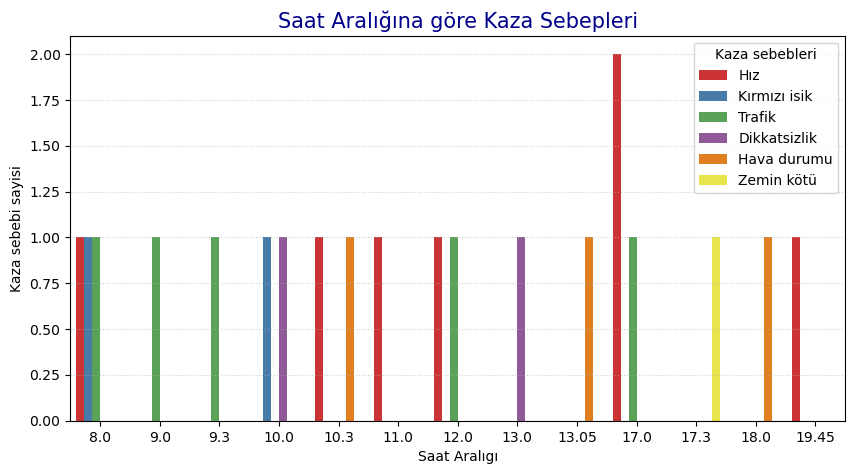

In [1]:
import pandas as pd 
import seaborn as sns #veri görselleştirme 
import matplotlib.pyplot as plt # veri görselleştirme


kazaVerileri={
    "il":["İstanbul","Antalya","Lüleburgaz","Tekirdağ","Mersin",
                "Ankara","Edirne","Iğdır","Mardin","İstanbul","Ankara","İzmir","Ankara","Şanlıurfa","Aksaray",
          "Burdur","Hatay","Uşak","Ağrı","Iğdır"],
    "Mevsim":["Kış","Yaz","İlkbahar","İlkbahar","Kış","İlkbahar","Yaz","Sonbahar","İlkbahar","Kış","Yaz","İlkbahar","Kış",
    "Sonbahar","İlkbahar","İlkbahar","Yaz","Sonbahar","Yaz","Kış"],
    "ortalamaHız":[100,30,90,90,120,30,50,50,90,120,80,50,80,30,30,100,130,100,50,30],
    "kazaSebebi":["Hız","Trafik","Kırmızı isik","Hava durumu","Hız","Dikkatsizlik","Hız","Hız","Hız",
                  "Hız","Hava durumu","Trafik","Hava durumu","Kırmızı isik","Dikkatsizlik","Zemin kötü","Trafik","Trafik","Hız","Trafik"],   
    "aracSayisi":[200000,70000,14000,5000,10000,130000,10000,5000,30000,200000,130000,100000,130000,20000,8000,7000,12000,16000,5000,6000],
    "saatAraligi":[08.00,09.00,08.00,13.05,10.30,10.00,12.00,17.00,17.00,19.45,18.00,08.00,10.30,10.00,13.00,17.30,17.00,
                   09.30,11.00,12.00], 
    "havaDurumu":["Yağmurlu","Karlı","Yağmurlu","Yağmurlu","Karlı","Güneşli","Yağmurlu","Rüzgarlı","Rüzgarlı","Yağmurlu",
                  "Karlı","Bulutlu","Güneşli","Rüzgarlı","Karlı","Yağmurlu","Karlı","Rüzgarlı","Yağmurlu","Güneşli"]
}

df=pd.DataFrame(kazaVerileri)
#print(df)

print("Sözlük Boyutu",df.ndim)
print("SÖzlük şekli",df.shape)

plt.figure(figsize=(10,5))

sns.countplot(data=df, x="saatAraligi", hue="kazaSebebi",palette="Set1")#palette="Set1" içine alıjnarak trenk paleti belirleme
plt.title("Saat Aralığına göre Kaza Sebepleri",color="darkblue",size="15")
plt.xlabel("Saat Aralıgı")
plt.ylabel("Kaza sebebi sayisi")
plt.legend(title="Kaza sebebleri")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.show()

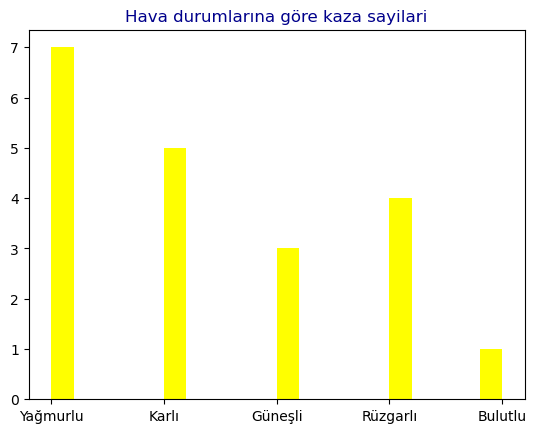

In [2]:
plt.hist(kazaVerileri["havaDurumu"],20,color="yellow")
plt.title("Hava durumlarına göre kaza sayilari",color="darkblue")
plt.show()

Koşul sağlayan histogram grafiği


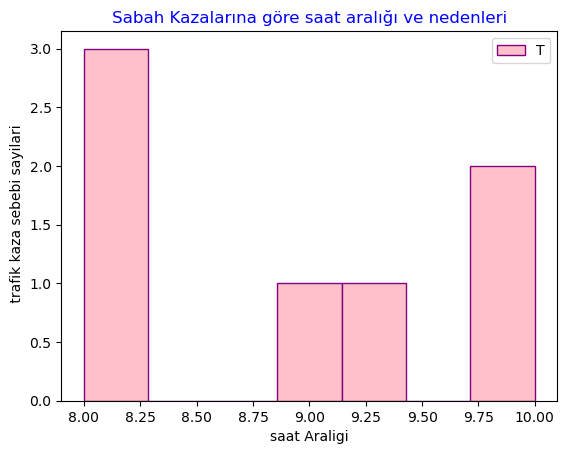

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.DataFrame(kazaVerileri)

filteredData = df[df['saatAraligi'] <= 10.00]
trafikKosulu=filteredData[(filteredData['kazaSebebi']=='Trafik') & (filteredData['saatAraligi']< 10.00)]
#print(filteredData)
if not trafikKosulu.empty:
    print("Koşul sağlayan histogram grafiği")
    plt.hist(filteredData["saatAraligi"], bins=7, color="pink" ,edgecolor="purple")
    plt.title("Sabah Kazalarına göre saat aralığı ve nedenleri",color="blue")
    plt.legend("Trafik")
    plt.xlabel("saat Araligi")
    plt.ylabel(" trafik kaza sebebi sayilari")
    plt.show()
else:
    print("HATA!! DİKKAT!!!")


Mevsime göre kaza risk oranı
Mevsim
İlkbahar    7
Kış         5
Yaz         5
Sonbahar    3
Name: count, dtype: int64
en fazla riskli mevsim: İlkbahar
en az riskli mevsim: Sonbahar
ortalama Risk mevsimi değeri 5.0
Kaza riski yüksek.


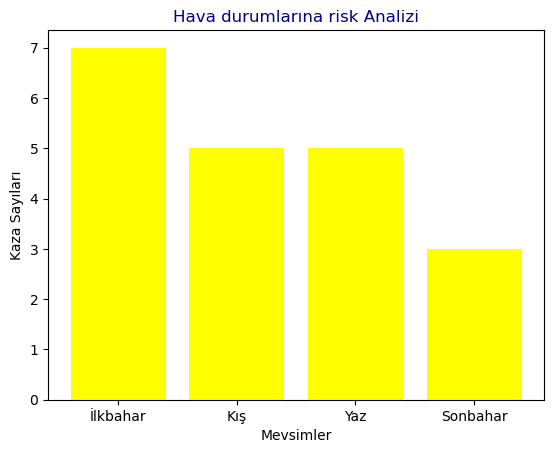

In [4]:
#mevsimlere göre kaza risk analizi
mevsimRiski=df["Mevsim"].value_counts()
print(f"Mevsime göre kaza risk oranı")
print(mevsimRiski)
enFazlaRiskliMevsim=mevsimRiski.idxmax()
print(f"en fazla riskli mevsim:",enFazlaRiskliMevsim)
enAzRiskliMevsim=mevsimRiski.idxmin()
print("en az riskli mevsim:",enAzRiskliMevsim)
ortalamaDegerRiski=mevsimRiski.mean()
print("ortalama Risk mevsimi değeri",ortalamaDegerRiski)
def yorumlama():
    s=ortalamaDegerRiski
    if s<3:
        return"Kaza riski düsük"
    elif s <5:
        return"Kaza riski orta."
    else:
        return"Kaza riski yüksek."
print(yorumlama())
plt.bar(mevsimRiski.index,mevsimRiski.values,color="yellow")
plt.title("Hava durumlarına risk Analizi",color="darkblue")
plt.xlabel("Mevsimler")
plt.ylabel("Kaza Sayıları")
plt.show()


illere göre kaza riski:
            il  aracSayisi  kazaSayisi
0      Aksaray        8000           1
1       Ankara      130000           3
2      Antalya       70000           1
3         Ağrı        5000           1
4       Burdur        7000           1
5       Edirne       10000           1
6        Hatay       12000           1
7        Iğdır        5000           1
8        Iğdır        6000           1
9   Lüleburgaz       14000           1
10      Mardin       30000           1
11      Mersin       10000           1
12    Tekirdağ        5000           1
13        Uşak       16000           1
14    İstanbul      200000           2
15       İzmir      100000           1
16   Şanlıurfa       20000           1


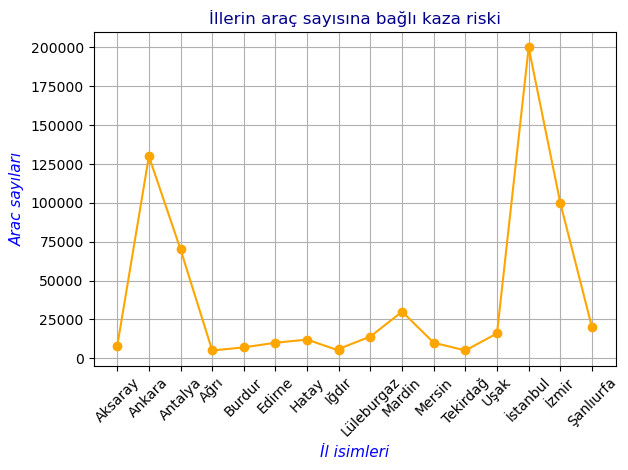

In [5]:

#araç sayisi ve illere göre 
#plot grafiği 

ilVeAracSayisiRiski=df.groupby(["il","aracSayisi"]).size().reset_index(name='kazaSayisi')
print("illere göre kaza riski:")
print(ilVeAracSayisiRiski)

#ilVeAracSayisi
plt.plot(ilVeAracSayisiRiski['il'],ilVeAracSayisiRiski['aracSayisi'],marker="o",color="orange")
plt.title("İllerin araç sayısına bağlı kaza riski",color="darkblue")
plt.grid(True)
plt.xlabel("İl isimleri",color="blue",style="italic",size=11)
plt.ylabel("Arac sayıları",color="blue",style="italic",size=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


            il  riskSkoru riskSinifi
0     İstanbul  83.076923     Yüksek
1      Antalya  42.423077       Orta
2   Lüleburgaz  47.869231       Orta
3     Tekirdağ  46.519231       Orta
4       Mersin  64.192308       Orta
5       Ankara  41.423077       Orta
6       Edirne  33.038462      Düşük
7        Iğdır  32.288462      Düşük
8       Mardin  45.269231       Orta
9     İstanbul  87.692308     Yüksek
10      Ankara  62.961538       Orta
11       İzmir  41.538462       Orta
12      Ankara  57.961538       Orta
13   Şanlıurfa  29.923077      Düşük
14     Aksaray  38.123077      Düşük
15      Burdur  49.126923       Orta
16       Hatay  56.800000       Orta
17        Uşak  45.476923       Orta
18        Ağrı  32.288462      Düşük
19       Iğdır  27.823077      Düşük


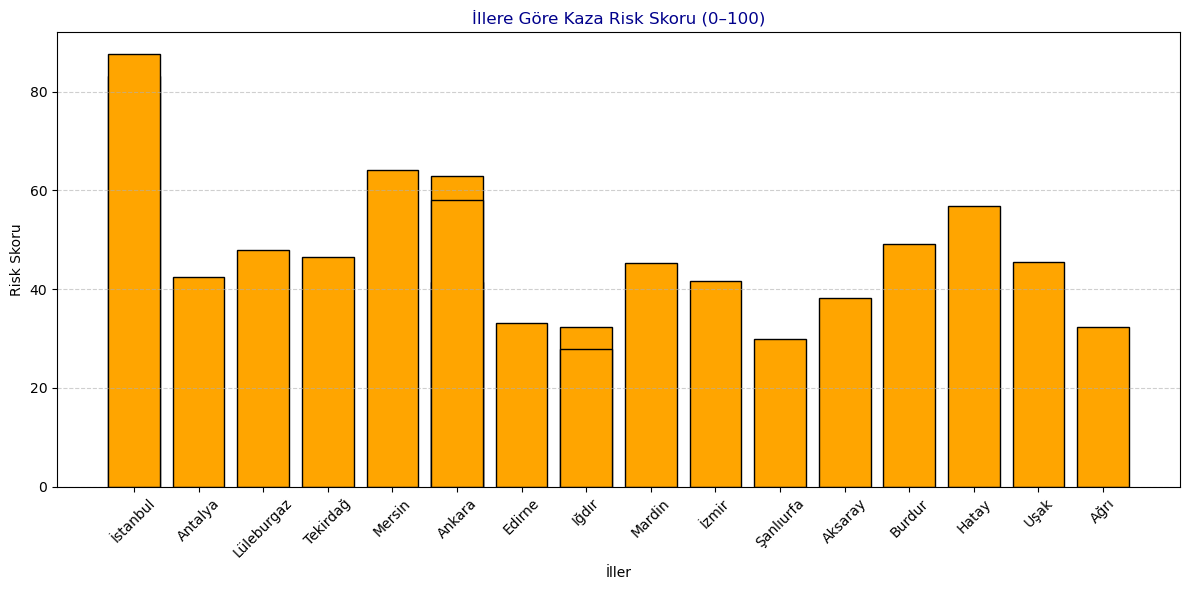

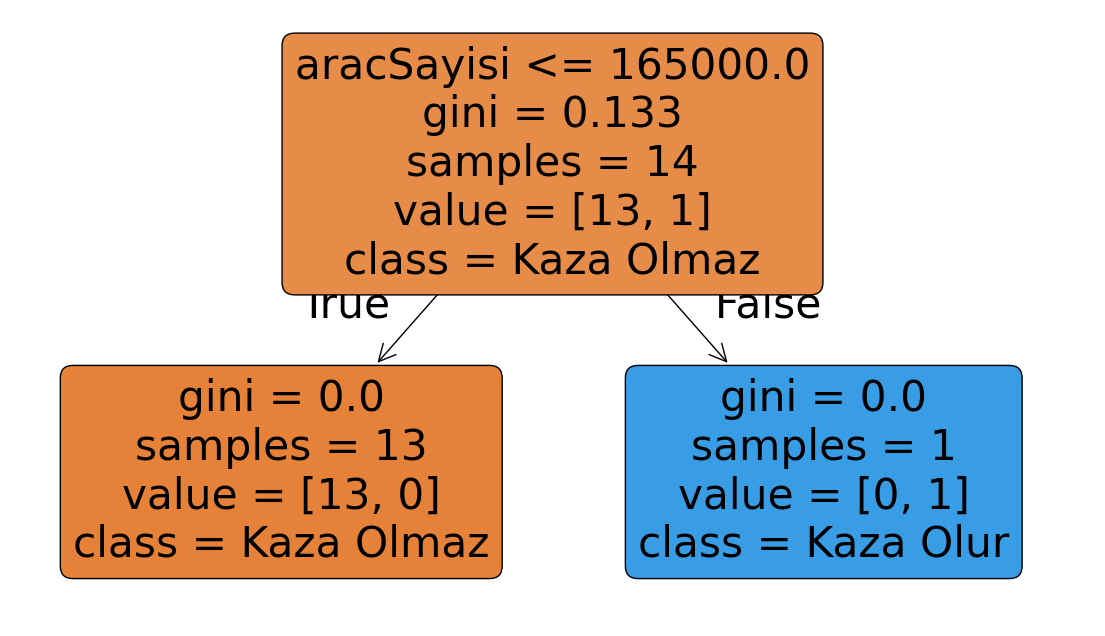

In [9]:
import pandas as pd

df = pd.DataFrame(kazaVerileri)

# Mevsim ve hava durumu için risk katsayıları
mevsimRisk = {
    "Kış": 3,
    "Sonbahar": 2,
    "İlkbahar": 2,
    "Yaz": 1
}

havaRisk = {
    "Karlı": 4,
    "Yağmurlu": 3,
    "Rüzgarlı": 2,
    "Bulutlu": 1,
    "Güneşli": 1
}

# Normalize edilmiş skor hesabı
df["hizSkor"] = (df["ortalamaHız"] / df["ortalamaHız"].max()) * 30
df["aracSkor"] = (df["aracSayisi"] / df["aracSayisi"].max()) * 30
df["mevsimSkor"] = df["Mevsim"].map(mevsimRisk) * 5   # max 20 puan
df["havaSkor"] = df["havaDurumu"].map(havaRisk) * 5   # max 20 puan

df["riskSkoru"] = df["hizSkor"] + df["aracSkor"] + df["mevsimSkor"] + df["havaSkor"]

# Sınıflandırma
def riskSinifi(skor):
    if skor < 40:
        return "Düşük"
    elif skor < 70:
        return "Orta"
    else:
        return "Yüksek"

df["riskSinifi"] = df["riskSkoru"].apply(riskSinifi)

print(df[["il","riskSkoru","riskSinifi"]])







import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(kazaVerileri)

# Mevsim ve hava durumu risk katsayıları
mevsimRisk = { "Kış": 3, "Sonbahar": 2, "İlkbahar": 2, "Yaz": 1 }
havaRisk = { "Karlı": 4, "Yağmurlu": 3, "Rüzgarlı": 2, "Bulutlu": 1, "Güneşli": 1 }

# Normalize edilmiş skor hesabı
df["hizSkor"] = (df["ortalamaHız"] / df["ortalamaHız"].max()) * 30
df["aracSkor"] = (df["aracSayisi"] / df["aracSayisi"].max()) * 30
df["mevsimSkor"] = df["Mevsim"].map(mevsimRisk) * 5
df["havaSkor"] = df["havaDurumu"].map(havaRisk) * 5

df["riskSkoru"] = df["hizSkor"] + df["aracSkor"] + df["mevsimSkor"] + df["havaSkor"]

# Grafik
plt.figure(figsize=(12,6))
plt.bar(df["il"], df["riskSkoru"], color="orange", edgecolor="black")
plt.title("İllere Göre Kaza Risk Skoru (0–100)", color="darkblue")
plt.xlabel("İller")
plt.ylabel("Risk Skoru")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()








from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Kopya veri
dfML = df.copy()

# Kategorik değişkenleri encode et
le = LabelEncoder()
dfML["Mevsim"] = le.fit_transform(dfML["Mevsim"])
dfML["havaDurumu"] = le.fit_transform(dfML["havaDurumu"])
dfML["il"] = le.fit_transform(dfML["il"])

# Risk sınıfını hedef olarak oluştur
dfML["kazaOlurMu"] = df["riskSkoru"].apply(lambda x: 1 if x > 70 else 0)

# Özellikler ve hedef
X = dfML[["ortalamaHız","aracSayisi","Mevsim","havaDurumu"]]
y = dfML["kazaOlurMu"]

# Eğitim
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

clf = DecisionTreeClassifier(max_depth=4)
clf.fit(X_train, y_train)

# --- Karar Ağacı Çizimi ---
plt.figure(figsize=(14,8))
plot_tree(
    clf,
    feature_names=["ortalamaHız","aracSayisi","Mevsim","havaDurumu"],
    class_names=["Kaza Olmaz","Kaza Olur"],
    filled=True,
    rounded=True
)
plt.show()
